In [2]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,5)

In [3]:
orders = pd.read_csv("../data/olist_orders_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
customers = pd.read_csv("../data/olist_customers_dataset.csv")

In [4]:
orders.head()
orders.info()
orders.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [5]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

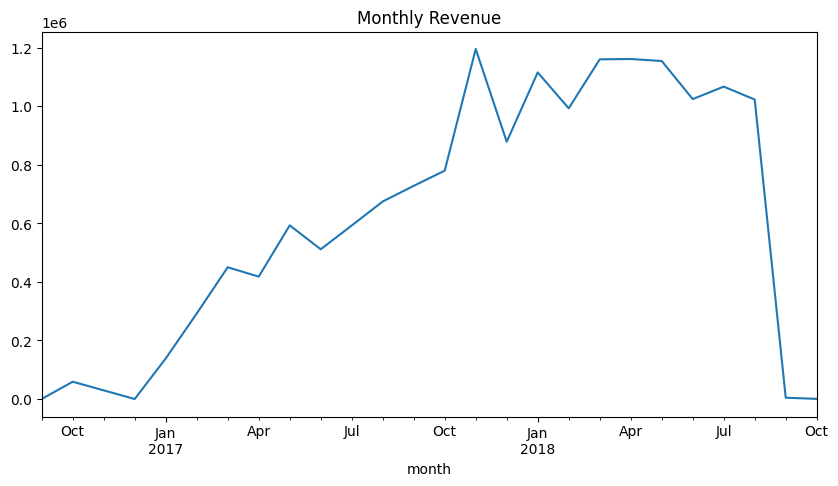

In [ ]:
df = orders.merge(payments, on="order_id")
df["month"] = df["order_purchase_timestamp"].dt.to_period("M")
revenue = df.groupby("month")["payment_value"].sum()
revenue.plot(title="Monthly Revenue")
plt.show()

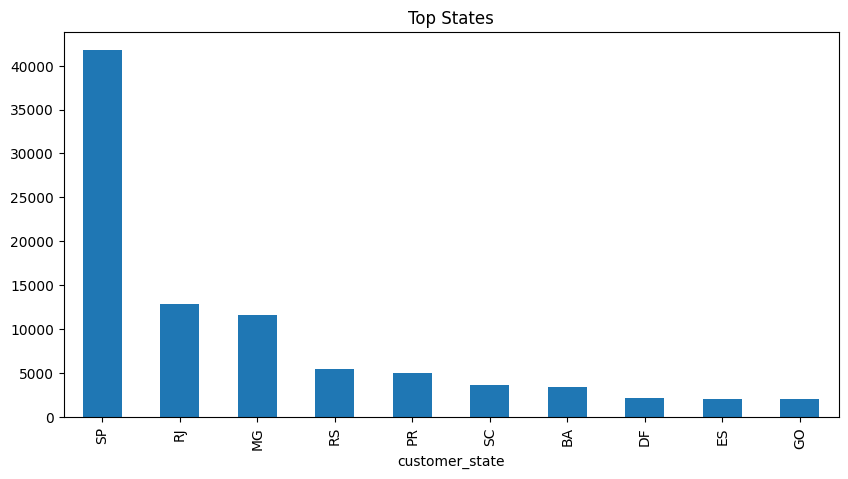

In [ ]:
df2 = orders.merge(customers, on="customer_id")
top_states = df2["customer_state"].value_counts().head(10)
top_states.plot(kind="bar", title="Top States")
plt.show()